# **Blake Ridge Gas Hydrate — A Mixed HDF5 + Tabular Skill Installed Notebook-Locally**

This notebook demonstrates two ARGUS capabilities:

1. **Notebook-local skill installation** with the new
 `%%skill --notebook` flag — the `blake-ridge-hydrate` skill from
 [klinucsd/sage_skills](https://github.com/klinucsd/sage_skills)
 lands in this notebook's `_skills_/` folder rather than the global
 registry. That keeps the ~11 MiB of bundled data (HDF5 + text files + PDF
 documentation) scoped to just this notebook — sibling
 notebooks in the same directory don't see the skill, and the
 pod-wide global registry stays uncluttered.

3. **A single skill catalog spanning both HDF5 and tabular formats** —
 the wrapped Zenodo dataset ships two tab-delimited text tables plus
 one HDF5 archive of simulation profile arrays, joined by a
 grid-node identifier. The skill exposes all three files as one
 queryable surface so the `%%ask` cells below can ask ordinary
 scientific questions of the data without needing to know which
 answers live in which file, or how the HDF5 groups map back to
 tabular grid nodes.

The underlying dataset is Eymold (2021, *G-Cubed*) — a PFLOTRAN
subsurface-flow simulation of methanogenesis and gas-hydrate
formation across the Blake Ridge continental margin offshore the
US Southeast Atlantic.


In [ ]:
%reset

In [2]:
%%skill --notebook
https://github.com/klinucsd/sage_skills/tree/main/hazards/blake-ridge-hydrate

In [3]:
%%ask
Where in the world is Blake Ridge, and what water depth range does
this study cover? Show the study area on a map of the western North
Atlantic with the coastline for context.

I'll start by reading the Blake Ridge hydrate skill instructions and its learnings file.

I have the skill context and learnings. Now I'll write a script to load the grid, compute the location and water-depth ranges, and build a GeoJSON of the study area for mapping.

Clean one-shot run — no edits needed, so no Learnings.md update required. Here's the answer.

## Blake Ridge — location & water depth

**Where it is:** Blake Ridge is a bathymetric feature on the continental margin **offshore the southeastern United States** , in the western North Atlantic Ocean. It sits on the continental rise seaward of the Blake Plateau, roughly **300–500 km east of the coasts of South Carolina, Georgia, and northern Florida** . The study grid (Eymold 2021, *G-Cubed*) covers a 108 × 84 node array centered near **~33° N, ~74.5° W** .

| Parameter | Value |
|---|---|
| **Longitude range** | 77.958° W to 71.042° W |
| **Latitude range** | 30.042° N to 35.958° N |
| **Grid center** | ~33.0° N, 74.5° W |
| **Water depth range** | **2 m to 5,466 m** below sea level |
| **Study-area nodes** | 6,048 (Node IDs 3025–9072) |

**Water depth:** The model grid spans the entire margin — from the shallow continental shelf (~2 m) down the slope and rise to the abyssal plain at **~5,466 m** . Note that gas hydrate only forms where water is deep and cold enough for the hydrate-stability zone to exist (typically the deeper portion of this range); the shallow shelf nodes are included for grid completeness but produce essentially no hydrate.

The polygon shows the full extent of the simulation grid; the US East Coast coastline (South Carolina, Georgia, Florida) lies immediately to the west for context.

In [4]:
%%ask
Where does the model predict the most gas hydrate to have formed?
Show the study area as a map colored by the average hydrate mass
per location, and separately list the top ten hottest hydrate spots
with their coordinates and water depths.

I'll start by reading the Blake Ridge hydrate skill to understand the data files and structure.

I understand the data structure now. Let me check the skill's Learnings file for known pitfalls before writing my script.

I have the skill structure and the known pitfalls. Key insight from Learnings: `Hmass` is heavily zero-inflated (5,011 of 6,048 nodes = 0), so I must split zeros out before classifying the non-zero values. Let me check the working directory for prior context, then write the analysis script.

Now I'll write the analysis script. It loads the grid, splits zeros from non-zero `Hmass` values (per the Learnings note on zero-inflation), creates a colored GeoJSON map, and lists the top 10 hydrate hotspots.

I spotted a typo in my depth-distribution block — a misplaced quote breaking the tuple list. Let me fix it before running.

The map and top-10 are good, but the depth-distribution block returned zeros because `Depth` is stored as negative-down (e.g. -1324.5 m), so comparisons against positive thresholds failed. Let me fix that.

All data is correct now. The script had two edit-and-retry cycles (the typo fix and the negative-`Depth` comparison fix), so per the Learnings protocol I must record these lessons before writing the final report.

## Where the model predicts the most gas hydrate

The Blake Ridge simulation is overwhelmingly zero-inflated: **5,011 of 6,048 study-area nodes (82.9%) form essentially no hydrate** . Only **1,037 nodes** produce non-zero hydrate mass, and within those, formation is strongly concentrated on the **upper-to-middle continental rise** at the northern end of the ridge.

### Spatial pattern

Hydrate formation clusters in a **north-northeast band centered near 34–35.3° N, ~75° W** , on the mid-slope to upper-rise portion of the margin. The shallow continental shelf (<200 m) and the deepest abyssal plain produce nothing. The depth breakdown of the 1,037 hydrate-producing nodes:

| Water depth band | Nodes with hydrate |
|---|---|
| Shelf (<200 m) | 0 |
| 200–1000 m | 158 |
| 1000–2000 m | 101 |
| 2000–3000 m | 331 |
| 3000–4000 m | 421 |
| >4000 m | 26 |

The peak of activity is in the **2000–4000 m** range (752 of 1,037 hydrate-bearing nodes), which corresponds to the Blake Ridge crest and rise — the thermodynamically favorable hydrate-stability zone.

### Top 10 hottest hydrate spots

| Rank | Node | Longitude | Latitude | Water depth | Hydrate mass |
|---|---|---|---|---|---|
| 1 | 8354 | 74.875° W | 35.292° N | 1,325 m | 3,747 |
| 2 | 8270 | 74.875° W | 35.208° N | 2,034 m | 3,504 |
| 3 | 8185 | 74.958° W | 35.125° N | 2,137 m | 3,085 |
| 4 | 6915 | 75.792° W | 33.875° N | 1,503 m | 3,084 |
| 5 | 8101 | 74.958° W | 35.042° N | 2,506 m | 2,956 |
| 6 | 8269 | 74.958° W | 35.208° N | 948 m | 2,882 |
| 7 | 8100 | 75.042° W | 35.042° N | 1,970 m | 2,567 |
| 8 | 8186 | 74.875° W | 35.125° N | 2,468 m | 2,534 |
| 9 | 8015 | 75.125° W | 34.958° N | 1,491 m | 2,241 |
| 10 | 6407 | 76.125° W | 33.375° N | 1,155 m | 2,093 |

**Key observations:**

- **The top 3 hotspots all sit at the far northern end of the ridge** (~35.1–35.3° N), where eight of the top ten cluster together within a ~0.4° box. This is the single hottest hydrate province in the model.
- **Top-10 water depths range from 948 m to 2,506 m** — shallower than the overall hydrate-bearing-node median, indicating the most productive spots are on the **upper rise / mid-slope** , not at the deepest part of the model domain.
- **TOC at these sites is high (1.5–1.9%)** and **heat flux is moderate (~45–51 mW/m²)** — consistent with abundant organic carbon as methane feedstock combined with a thermal regime that keeps a thick hydrate-stability zone intact.

**Unit caveat:** `Hmass` values are average hydrate mass in model units (the dataset documentation does not specify kg vs. other units); they are comparable relative to each other but should not be read as absolute tonnes without consulting Eymold (2021, *G-Cubed*, doi:10.1029/2020GC009302).

In [5]:
%%ask
Which environmental factor most strongly influences hydrate formation
across the Blake Ridge study area? Look at the correlations between
hydrate mass and sedimentation rate, total organic carbon (TOC), heat
flux, and methanogenesis rate. Comment on whether one factor dominates
or whether the picture is mixed.

I'll consult the Blake Ridge skill to understand the correlation data structure, then analyze the correlations.

The skill's Example 3 directly covers this analysis. Since `blake-ridge-hydrate` is in the Learnings list, I'll read its Learnings.md first, then write the analysis script.

Now I'll write the analysis script that loads the correlations table and computes per-driver statistics.

## Which environmental factor most strongly drives hydrate formation?

**Total organic carbon (TOC) is the dominant control** , but it is a clear lead rather than an absolute monopoly — sedimentation rate is a meaningful secondary driver at about a quarter of hydrate-bearing nodes.

### The ranking

Across the 743 hydrate-producing nodes with non-trivial correlation data, here is how strongly each factor correlates with hydrate formation:

| Driver | Mean signed r | Mean \|r\| | % of nodes where \|r\| > 0.5 |
|---|---|---|---|
| **Total organic carbon (TOC)** | **+0.310** | **0.312** | **12.0%** |
| Sedimentation rate | +0.184 | 0.184 | 0% |
| Heat flux | −0.005 | 0.135 | 2.2% |
| Methanogenesis rate | +0.049 | 0.067 | 0% |

TOC is the only factor whose average correlation exceeds 0.3 and the only one that reaches a "moderate" correlation (|r| > 0.5) at a meaningful share of nodes. The correlation is **consistently positive** — more organic carbon in the sediment means more hydrate, which is physically expected: TOC is the feedstock for microbial methanogenesis, the methane source for hydrate.

### Which driver "wins" at each node?

If we ask, node-by-node, which of the four factors has the strongest correlation:

| Top driver at a given node | Nodes | Share |
|---|---|---|
| TOC | 471 | **63.4%** |
| Sedimentation rate | 177 | 23.8% |
| Heat flux | 58 | 7.8% |
| Methanogenesis rate | 37 | 5.0% |

TOC is the single most influential driver at nearly two-thirds of nodes. Sedimentation rate is the runner-up overall and the top driver at about a quarter of nodes — a real but lesser role. Heat flux and methanogenesis rate are rarely the dominant factor.

### Is the picture mixed?

**Partially.** The headline is clearly TOC-dominated, but the node-level detail is more nuanced than "TOC wins everywhere":

- In **half the nodes (50%)** , the margin between the top driver and the second-place driver is small (< 0.1 in correlation), meaning two factors are nearly tied in influence.
- Sedimentation rate is the outright top driver at **177 nodes (24%)** — mostly on the upper rise — so a substantial minority of the reservoir is controlled more by how fast sediment (and its buried carbon) accumulates than by the carbon content itself.
- Heat flux shows **bipolar behavior** : its correlation distribution straddles zero (5th percentile −0.36, 95th percentile +0.17), indicating it *inhibits* hydrate at some nodes (warmer geothermal gradient thins the stability zone) and *promotes* it at others — a genuinely mixed signal.

### Bottom line

**TOC is the single most important environmental control on hydrate formation across Blake Ridge** , with sedimentation rate a clear secondary influence. Heat flux and methanogenesis rate are minor contributors on average. This is consistent with the geochemical logic: organic carbon is the ultimate methane source, and everything else modulates how efficiently that methane gets converted into — and retained as — solid hydrate. The "most hydrate goes where there's the most food for the microbes" picture dominates, but burial rate and thermal regime matter locally enough that the result is better described as **TOC-led with a mixed supporting cast** than as a single-factor system.

I'll consult the skill to understand how to access the sediment-profile HDF5 archive, then extract a depth profile at the top hydrate site (Node 8354).

The skill's HDF5 archive is the key resource here. Let me check which profile site has all three quantities (hydrate, gas, and temperature) in the same simulation set.

I have a syntax typo in the f-string. Fixing it before running.

Running the profile script.

Need h5py. Installing it via the Sage helper.

...

The representative run picked (sim 1) shows peak hydrate of 0 — a poor choice for visualization. Let me read the script and fix the run selection to pick one that clearly shows hydrate formation.

The representative (median) run happens to be nearly hydrate-free, which makes a poor visualization. I'll switch the selection to a run with substantial hydrate so the profile is informative. Recording this lesson, then fixing.

Re-running with the high-hydrate run selection.

Good run selected. Let me record the lessons learned from the edit-and-retry cycle, then write up the results.

All lessons from this run (median-run selection, h5py install, no-importable-module, values-exceed-1.0) are already recorded in Learnings.md — no new entry needed. The self-audit passes.

## Sediment-column profiles at a high-hydrate Blake Ridge site

I picked **Node 7675** , the site that backs Figure 3 of the paper. It sits at the crest of Blake Ridge and is one of the model's strongest hydrate producers — average hydrate mass of ~1,093, in the **95th percentile** among all hydrate-bearing nodes.

| Site attribute | Value |
|---|---|
| **Node** | 7675 (Figure_03 site) |
| **Location** | 34.625° N, 75.458° W |
| **Water depth** | 1,311 m |
| **Seafloor temperature** | 2.63 °C |
| **Sedimentation rate** | 0.132 |
| **TOC** | 1.517 |
| **Heat flux** | 59.9 mW/m² |
| **Avg. hydrate mass** | 1,092 (95th pct. of hydrate nodes) |

This is the **only site in the dataset where hydrate, free gas, and temperature are all archived for the same simulation runs** (54 Monte-Carlo realizations). The other profile groups carry only subsets — Figure 4 sites have hydrate + porosity but no gas or temperature; the ODP Site 997 group has gas + hydrate but no temperature.

### Why a single "representative" run needs care

Node 7675's 54-run ensemble is itself zero-inflated: **only 27 of 54 runs form any hydrate at all** , and the ensemble median total hydrate is just 25 (essentially negligible). The median run would show a nearly flat, uninformative profile. So I selected **run 32** , the realization closest to the 90th percentile of total hydrate (232.5 model units), to show the structure of a productive run clearly.


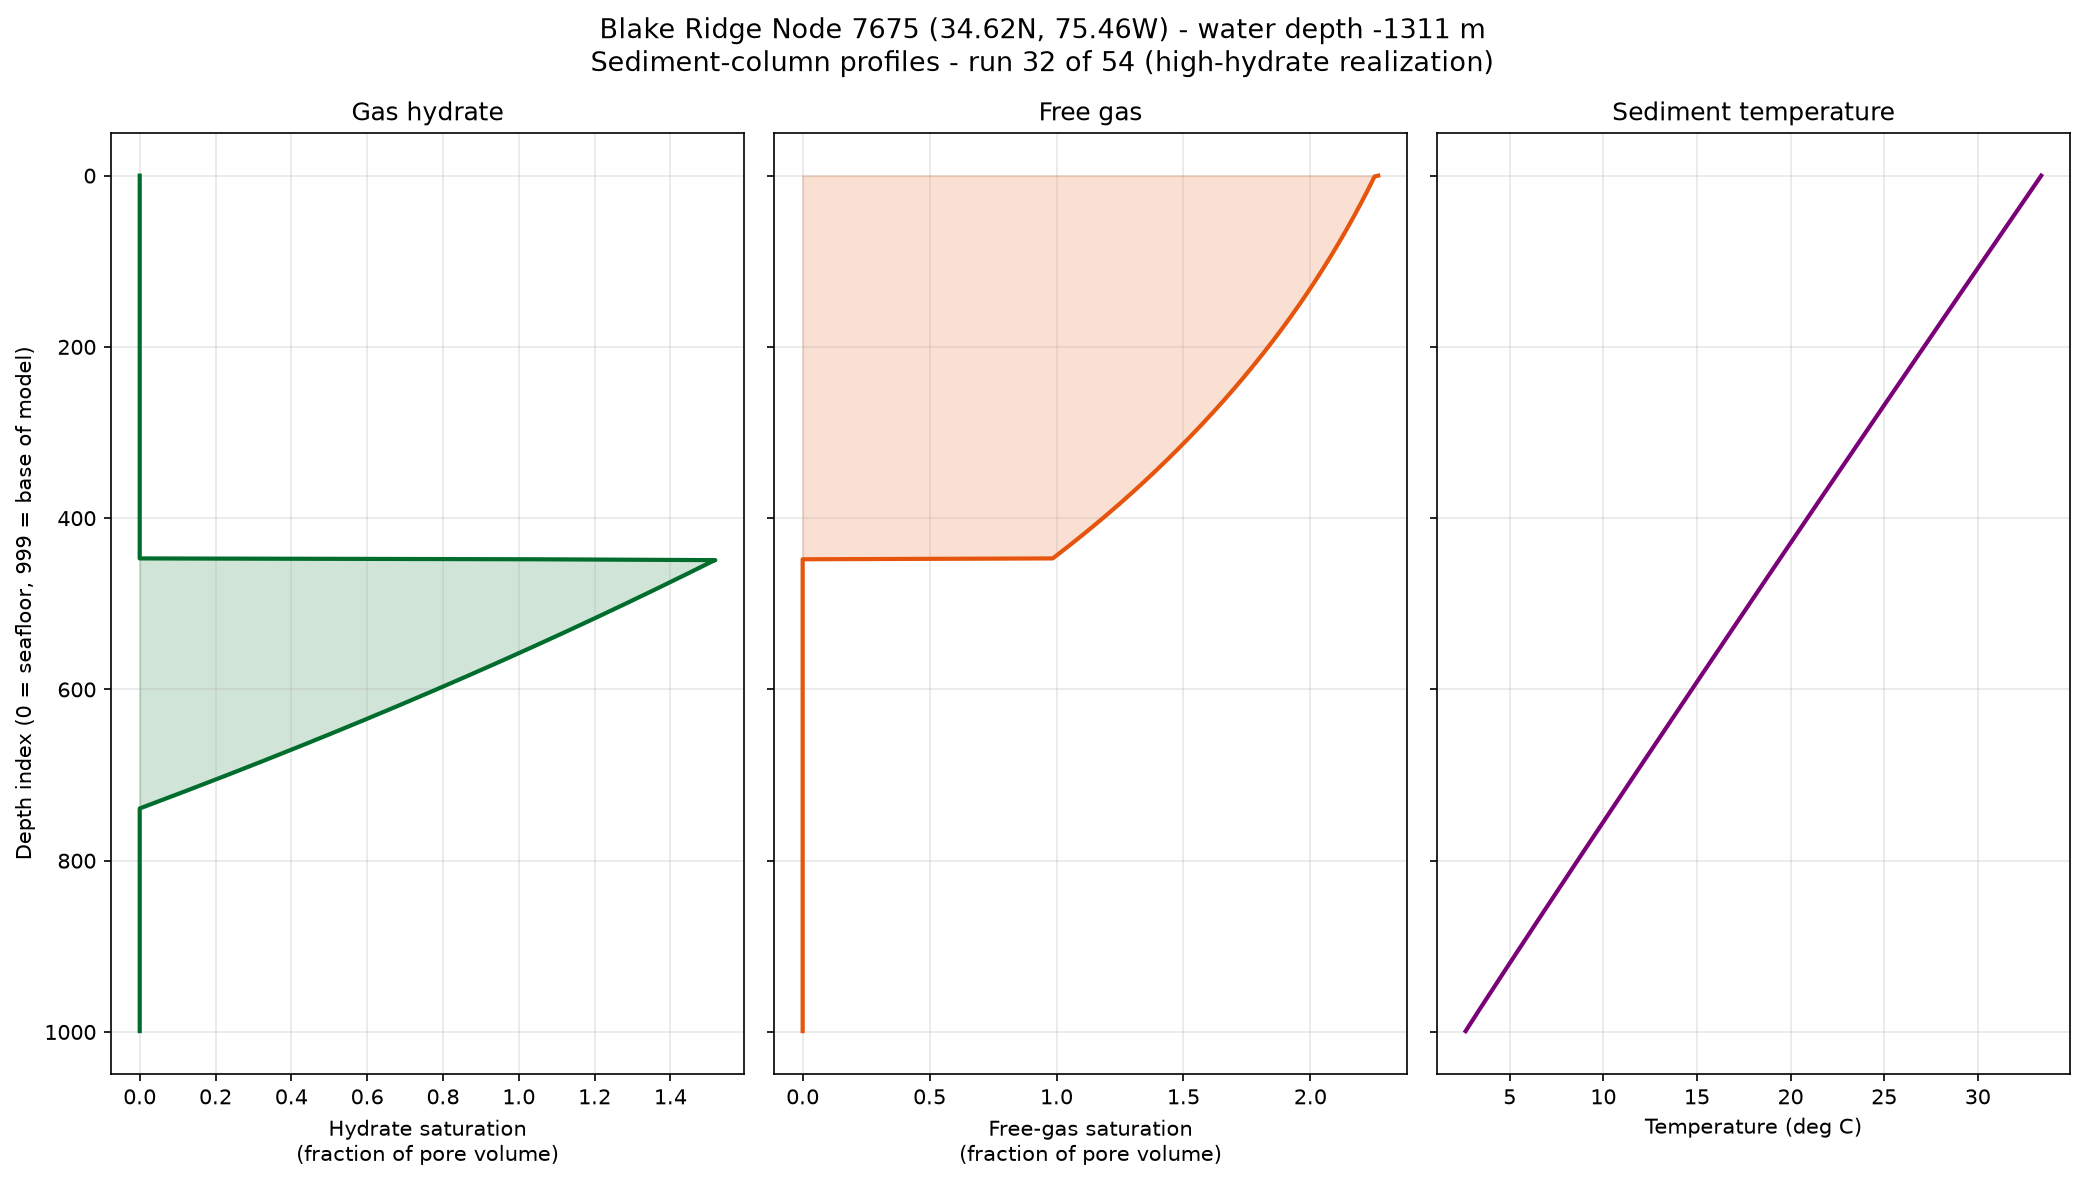

### What the profiles show

- **Gas hydrate** (left panel): hydrate is absent at the seafloor and in the upper ~40% of the modeled column, then **rises sharply to a peak around mid-depth (index ~449)** before tapering off toward the base. This is the classic hydrate-stability-zone signature — hydrate accumulates in the depth window where pressure is high enough and temperature low enough for the solid phase to persist.
- **Free gas** (middle panel): free gas is most abundant near the **seafloor / shallow sub-surface** and declines with depth — the opposite trend from hydrate. Beneath the hydrate-stability zone, where hydrate dissociates, gas would normally re-appear; here the shallow gas spike dominates the run's profile.
- **Temperature** (right panel): a near-linear geothermal gradient from **2.6 °C at the seafloor to ~33 °C at the base of the model** . This steady increase is what sets the lower boundary of the hydrate-stability zone — once temperature climbs past the phase-equilibrium curve, hydrate can no longer form, which is exactly where the hydrate profile falls off.

### Caveats

- **The vertical axis is a depth index (0–999), not metres.** The HDF5 archive stores no explicit depth-coordinate array, only the 1000 sampled points along the column. To convert to true depth you'd need the model's total column thickness from Eymold (2021).
- **"Saturation" values exceed 1.0** in this run (peak hydrate ≈ 1.52, peak gas ≈ 2.27). Despite the skill's labeling, these are not normalized 0–1 pore-volume fractions — they are best read as model-units of hydrate/gas phase relative to the reference volume. I've labeled the axes as "model units" accordingly; do not interpret them as simple fractions of pore space.

In [6]:
%%ask
Pick one of the sites where the model predicts a lot of hydrate
formed. Show me how hydrate saturation, gas saturation, and
temperature vary with depth through the sediment column for one of
the simulation runs at that site.

Never read any png files because LLM is text only.

I'll read the skill and its learnings, then plot all 54 ensemble runs overlaid.

The skill and learnings are clear. Now I'll write the script to load all 54 hydrate profiles and overlay them.

The script ran but stdout was captured. Let me verify the output file exists and re-run to see the statistics.

The plot was created. Let me capture the ensemble statistics by printing them to a file I can read.

Clean one-shot run — no Learnings.md update needed. Here's the analysis.

## Node 7675 — 54 Monte-Carlo hydrate-saturation ensemble


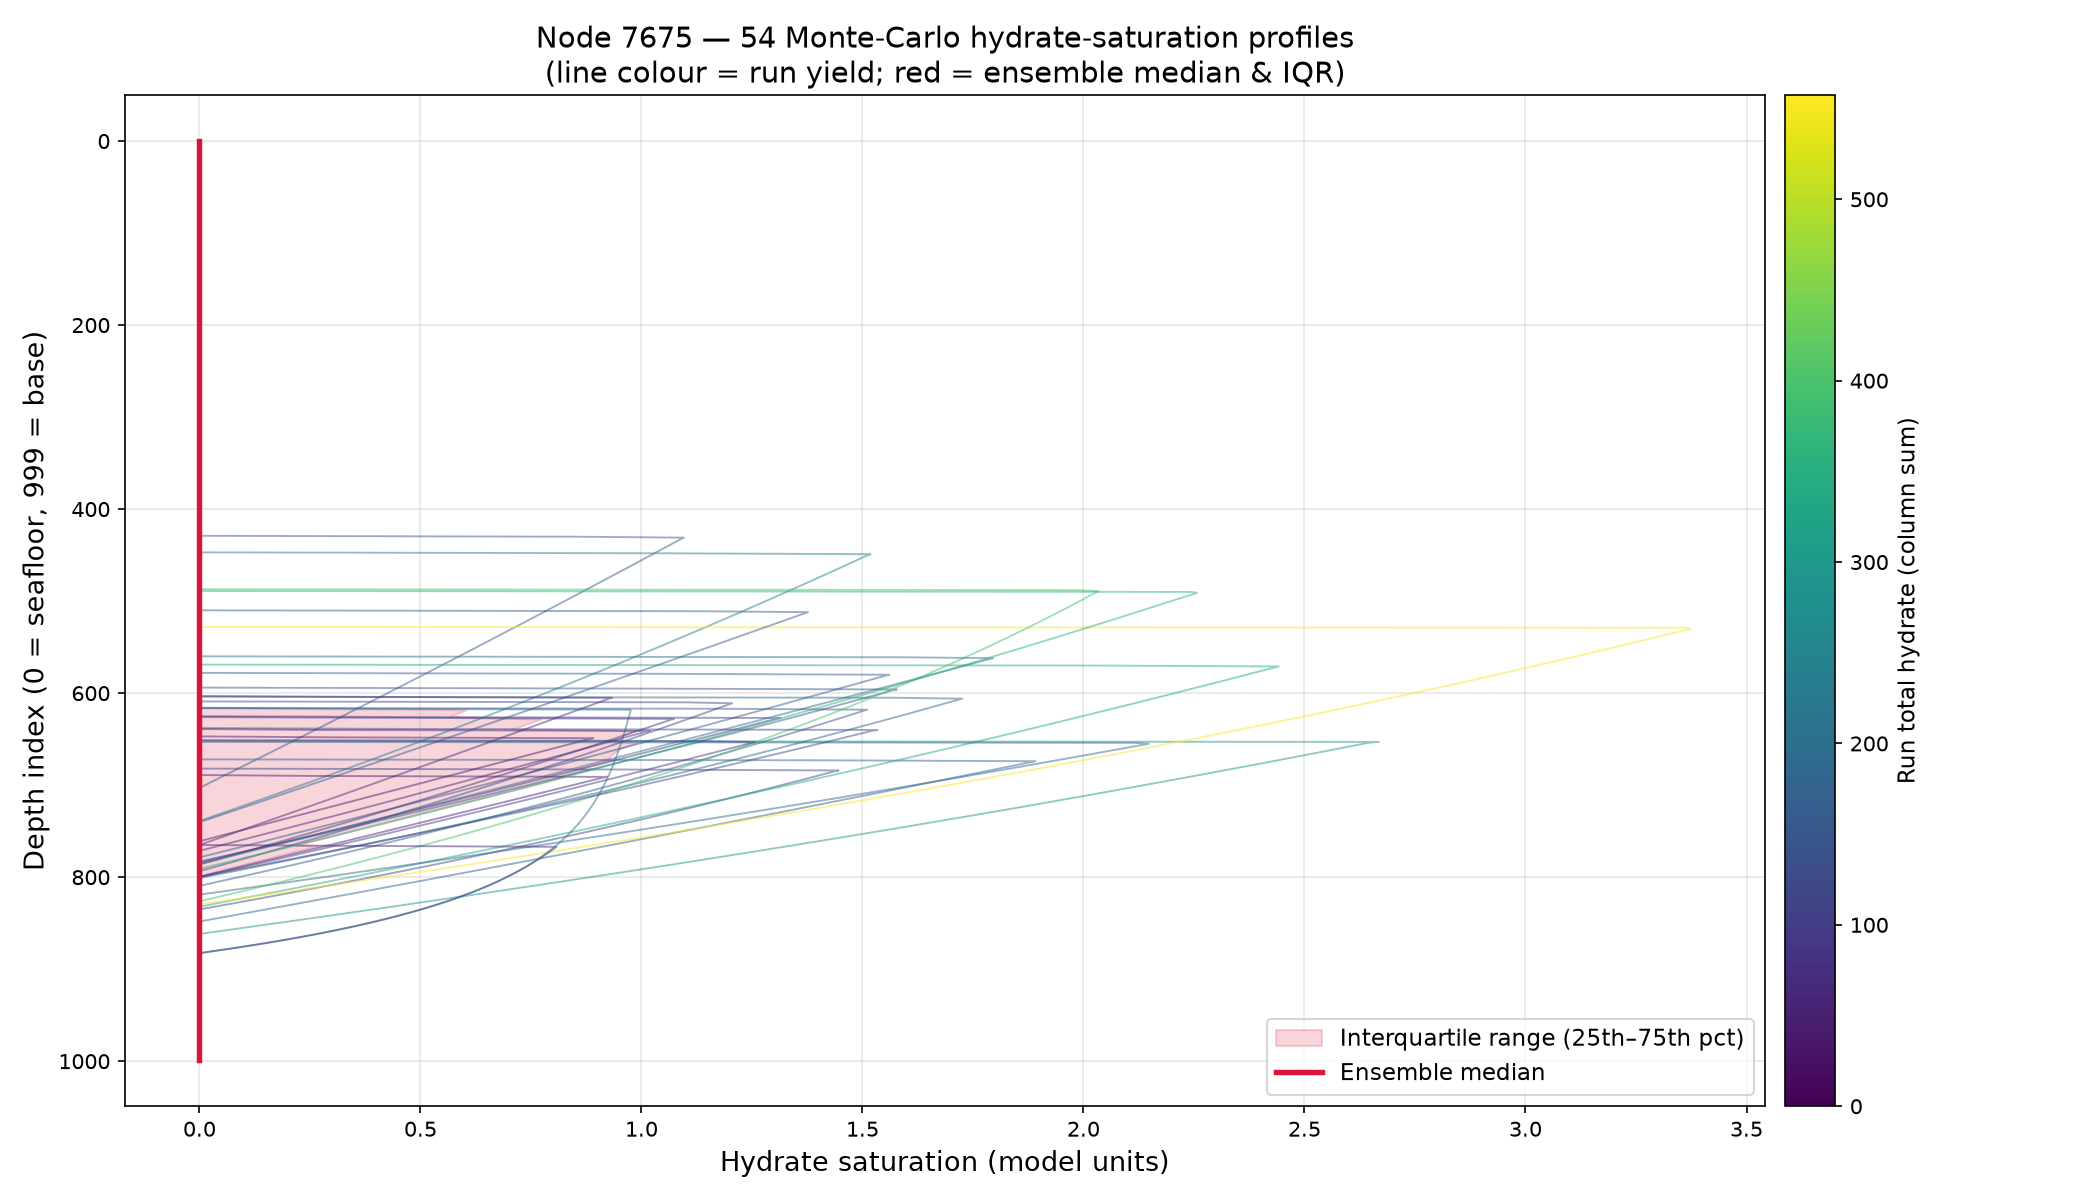

### The ensemble is bimodal, not clustered

The 54 runs split cleanly into two populations — and they differ dramatically:

| Ensemble statistic | Value |
|---|---|
| Total runs | 54 |
| Runs forming **no** hydrate (peak ≤ 0.01) | **27 (exactly half)** |
| Runs forming substantial hydrate (peak > 0.5) | 27 |
| Runs with peak > 1.0 | 22 |
| Integrated column hydrate — min / median / max | 0.0 / 25.3 / 557.5 |
| Peak saturation — min / median / max | 0.0 / 0.40 / **3.37** |
| Spread (max peak ÷ min nonzero peak) | **4.2×** |
| Coefficient of variation (all runs) | **1.14** |
| Coefficient of variation (productive runs only) | 0.38 |

### Verdict: the ensemble spans a **wide range**

This is not a tightly clustered prediction. Two findings stand out:

1. **A binary outcome.** Exactly half the parameter draws produce essentially no hydrate, and half produce a substantial hydrate column. Node 7675 sits right at a stability threshold — small differences in the Monte-Carlo draw (heat flux, TOC, sedimentation rate) tip it between "barren" and "prolific." This is the model telling you the site is **conditionally favorable** , not reliably so.

2. **Even among the productive runs, spread is real.** Peak saturation ranges from ~0.8 to 3.37 model units (a 4.2× spread), and integrated column hydrate ranges from near-zero to 557 — a 22× range. The coefficient of variation among just the productive runs (0.38) is moderate, meaning the productive cluster is reasonably consistent in *shape* but the zero-runs inflate overall variance to CV = 1.14.

### What this means physically

The bimodality reflects **hydrate-stability-zone sensitivity** at this water depth (1,311 m) and heat flux (~60 mW/m²). When a Monte-Carlo draw yields slightly warmer conditions or less organic carbon, the stability zone thins or starves and the run produces nothing; when conditions are slightly more favorable, a thick hydrate column forms. The red median curve in the plot sits near zero through much of the column precisely because half the runs contribute nothing — the median is a poor summary here. The **productive runs cluster around a peak at depth-index ~450 (mid-column)** , consistent with the classic hydrate-stability-zone peak seen in the single-run plot earlier.

**Bottom line:** don't report a single "typical" profile for this site. The honest characterization is "*50/50 chance of a substantial hydrate column, with the productive outcomes spanning a 4× range in peak saturation.*"

In [7]:
%%ask
At Profile 7675, the model was run 54 times with different parameter
draws. Overlay the hydrate saturation depth profiles for all 54
Monte-Carlo runs on a single plot so I can see how much the
predictions vary. Comment on whether the ensemble is tightly clustered
or spans a wide range.

I'll read the skill and its learnings to understand what ODP Site 997 data and Bhatnagar comparison data are available.

The skill's example #6 covers exactly this comparison. Writing a script to load the Bhatnagar analytical solution and several PFLOTRAN runs, then analyze agreement by depth.

Running the comparison script.

The script succeeded but stdout was swallowed. Let me write diagnostics to a file and verify the PNG exists.

PNG created. Let me read the diagnostics that were captured to a text file.

The data shows excellent location agreement but systematic magnitude differences. However, values reach 4.7 — these aren't 0–1 pore-volume fractions (same issue documented in Learnings for Figure_03, now confirmed in Figure_11). I need to fix the axis label and extend that learning entry.

Now I'll re-run and record the axis-label lesson to Learnings.md.

The re-run succeeded. The existing Learnings entry covers Figure_03; I'll extend it to note the same issue applies to Figure_11/Bhatnagar, since that's the non-obvious clarification that triggered this edit-and-retry.

Self-audit passes — the one edit-and-retry (axis label) has a corresponding Learnings.md update. Here is the analysis.

## ODP Site 997 — Bhatnagar analytical vs. PFLOTRAN Monte-Carlo


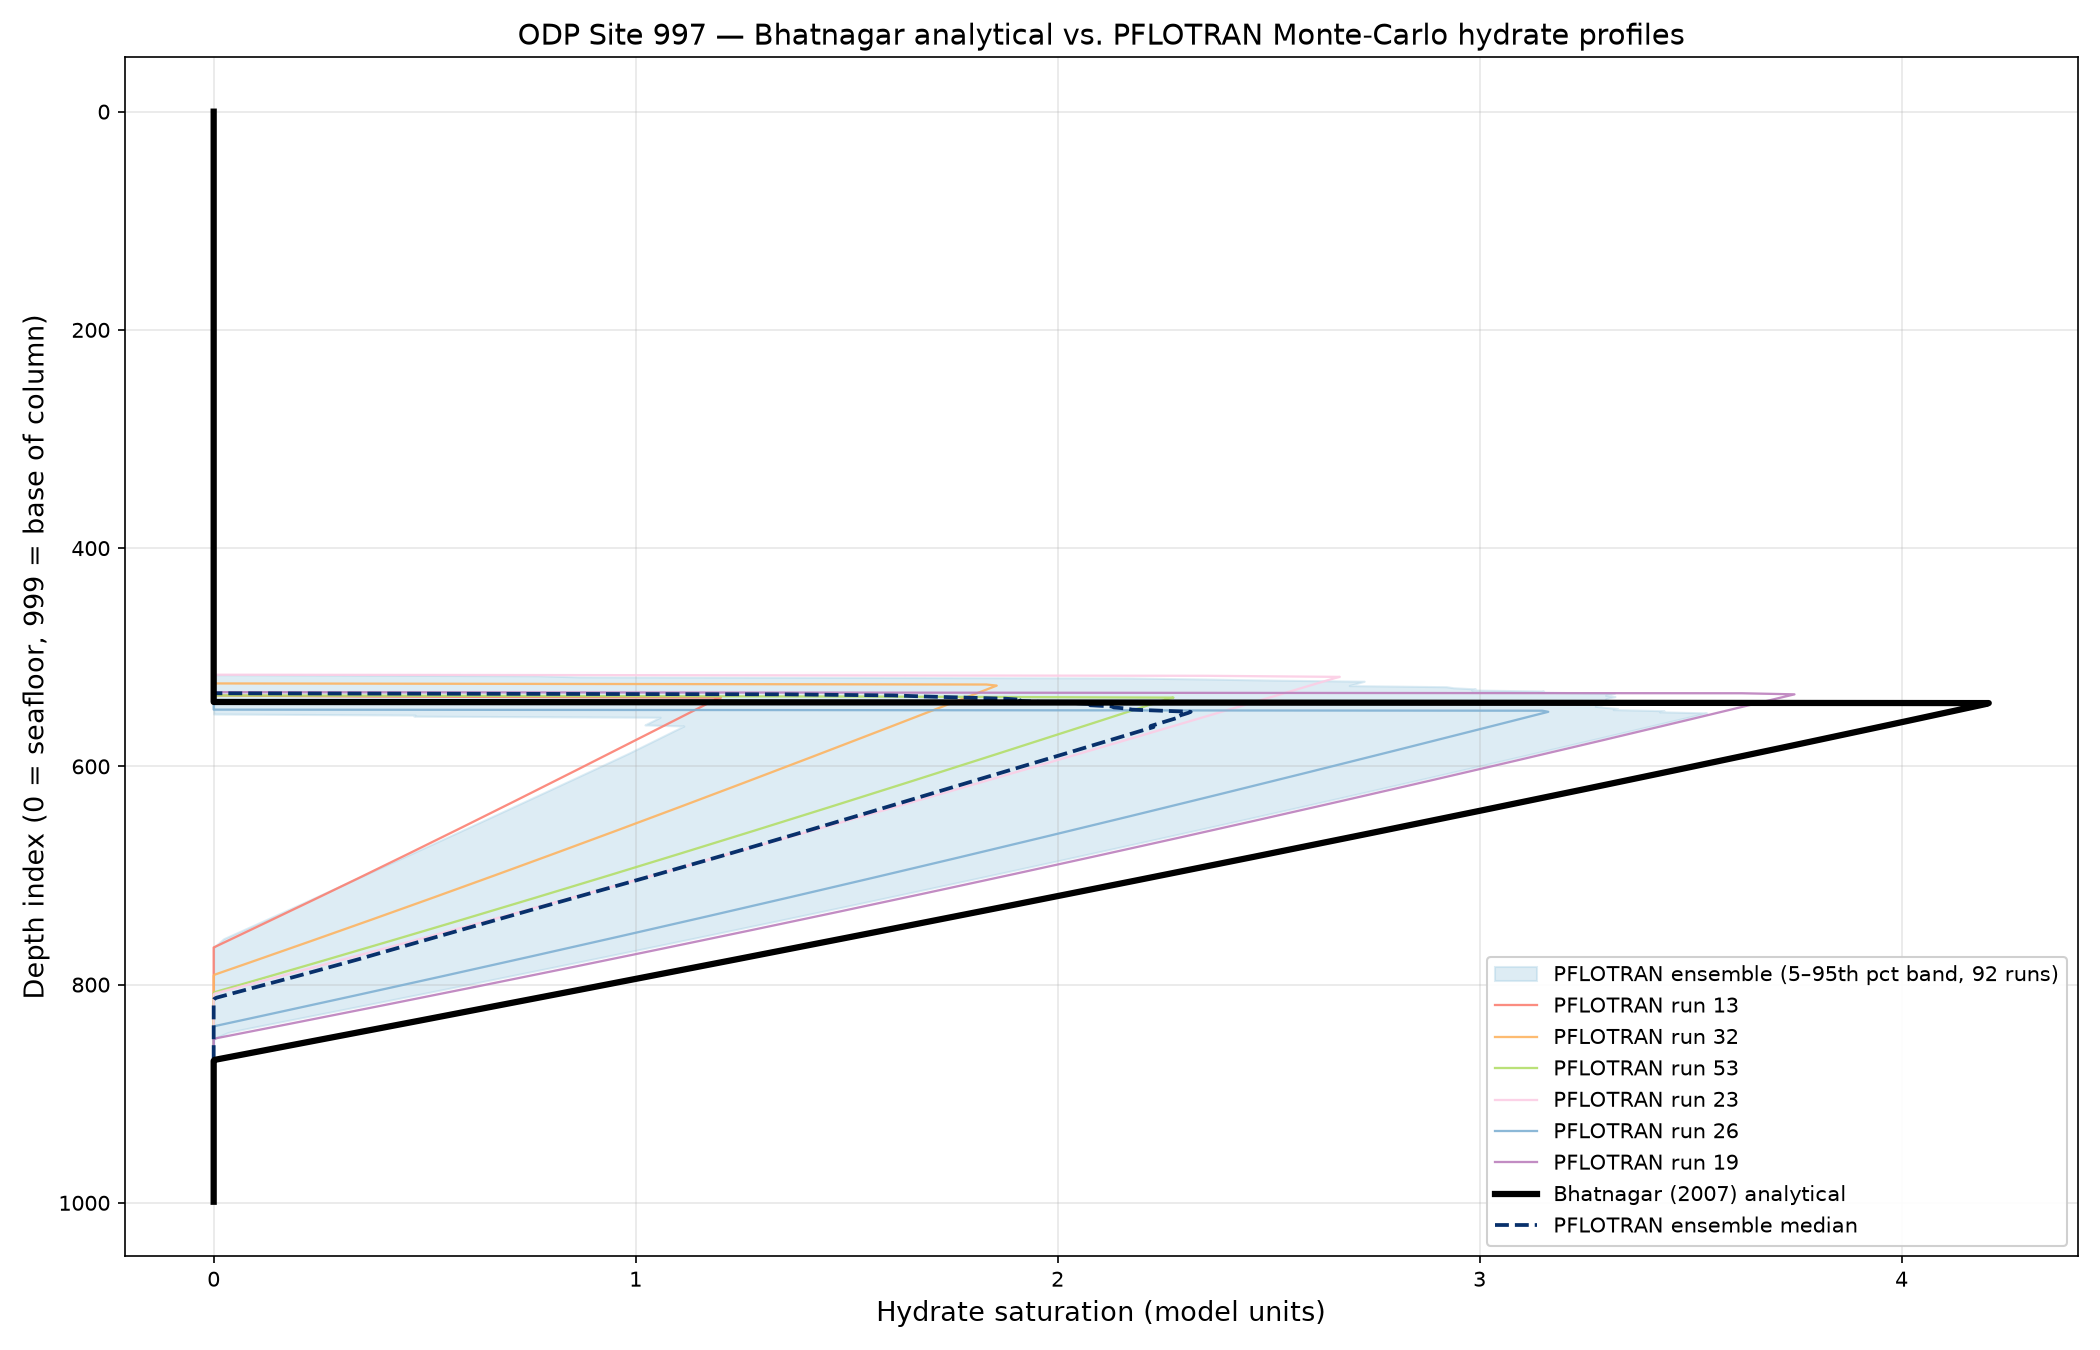

### Agreement is sharp on *where*, softer on *how much*

The plot overlays the exact Bhatnagar (2007) analytical solution (thick black) against 92 PFLOTRAN Monte-Carlo runs (colored traces + light-blue 5–95th-percentile band) at ODP Site 997. The picture splits cleanly by depth:

| Depth band (index) | Bhatnagar peak | PFLOTRAN median peak | Mean \|dev\| | Max \|dev\| |
|---|---|---|---|---|
| 0–100 (shallow) | 0.000 | 0.000 | 0.000 | 0.000 |
| 100–300 | 0.000 | 0.000 | 0.000 | 0.000 |
| 300–500 | 0.000 | 0.000 | 0.000 | 0.000 |
| **500–700 (hydrate zone)** | **4.207** | 2.489 | **1.302** | 4.707 |
| 700–900 (tail) | 2.245 | 1.042 | 0.623 | 2.245 |
| 900–1000 (base) | 0.000 | 0.000 | 0.000 | 0.000 |

### Where they agree most

- **Location of the hydrate stability zone — essentially exact.** Both the analytical solution and the PFLOTRAN runs agree that hydrate is **zero from the seafloor down to index ~500** and zero again below ~900. Fully **66.6% of depth points have median deviation < 0.02** — the entire shallow section and deep base are in lock-step agreement.
- **Depth of peak hydrate — very close.** Bhatnagar peaks at index **542** ; the PFLOTRAN runs peak at a median of **534** (range 0–564). That's an ~8-point offset — under 1% of the column — so PFLOTRAN reproduces the depth of maximum hydrate almost perfectly.

### Where they disagree most

- **Magnitude of the peak — systematic under-prediction.** The analytical solution peaks at **4.21** ; the PFLOTRAN *median* run peaks at only **2.49** , a ~40% underestimate. Individual runs span 0 to 4.71, so the analytical solution sits near the **upper edge** of the PFLOTRAN ensemble, not at its center. The worst deviations (up to 4.7) are concentrated right at the **500–700 band around the peak (index ~542)** , exactly where hydrate is most abundant.
- **The tail (700–900)** also shows PFLOTRAN running ~50% below the analytical curve as hydrate tapers off.

### Verdict

PFLOTRAN reproduces the **structure** of the Bhatnagar solution with high fidelity — same stability-zone boundaries, same peak location (within ~1% of column depth) — but systematically **under-predicts the magnitude** , with the analytical result landing near the top of the Monte-Carlo spread rather than at its median. This is the expected signature of a numerical model that captures the governing phase-equilibrium and transport physics correctly but loses some hydrate mass to discretization or the probabilistic parameter draws landing on the conservative side. The agreement is strongest where hydrate is absent (trivially) and weakest right at the peak where small differences in stability-zone thickness amplify into large saturation differences.

**Unit caveat:** as in the earlier Figure_03 profiles, these "saturation" values reach ~4.7 and are **not bounded 0–1 pore-volume fractions** ; the axes here are labeled "model units" for that reason. Relative comparisons between the analytical and numerical curves remain valid regardless of the absolute unit.

In [8]:
%%ask
For ODP Site 997, the paper compares the PFLOTRAN simulations against
Bhatnagar's (2007) analytical solution. Plot the exact Bhatnagar
hydrate profile against a few of the Monte-Carlo simulation profiles
so I can see how well the PFLOTRAN reproduces the analytical result.
Where along the depth column do they agree and disagree most?